In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


import warnings
warnings.filterwarnings("ignore")

In [38]:
df = pd.read_csv("Resume dataset.csv")

In [39]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (9000, 3)


In [40]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   category   9000 non-null   object
 1   job_title  9000 non-null   object
 2   Text       9000 non-null   object
dtypes: object(3)
memory usage: 211.1+ KB


In [41]:
# Missing Values

df.isnull().sum()

,0
category,0
job_title,0
Text,0


In [42]:
# Number of Categories

print(df["category"].value_counts())

category
Java Developers/Architects Resumes                1000
Web Developer Resumes                             1000
SQL Developers Resumes                            1000
Business Analyst (BA) Resumes                     1000
Network and Systems Administrators Resumes        1000
Datawarehousing, ETL, Informatica Resumes         1000
Business Intelligence, Business Object Resumes    1000
Project Manager Resumes                           1000
Recruiter Resumes                                 1000
Name: count, dtype: int64


In [43]:
# Number of Unique Job Titles

print("Unique Job Titles :", df["job_title"].nunique())

Unique Job Titles : 3691


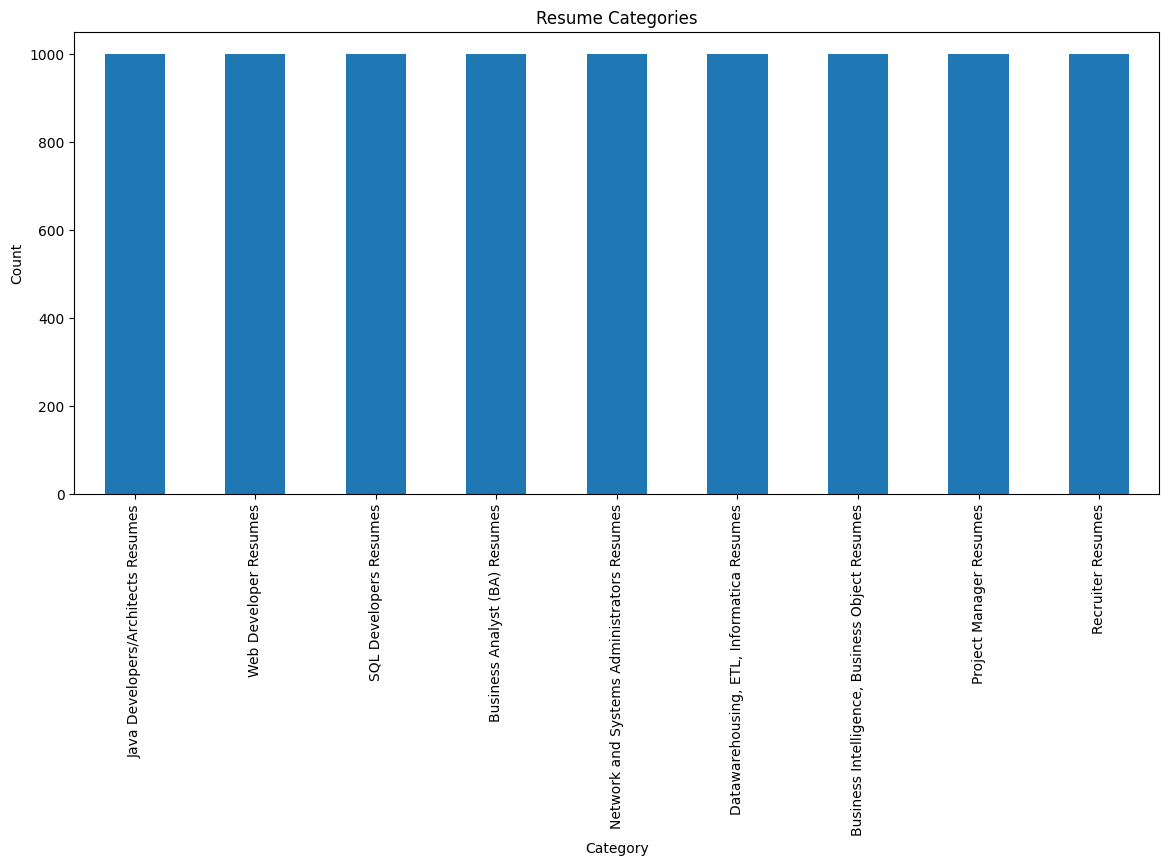

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

df["category"].value_counts().plot(kind="bar")

plt.title("Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

In [45]:
job_description = """
Looking for a Python Data Scientist with experience in Machine Learning,
Deep Learning, SQL, Pandas, NumPy, Scikit-learn,
Data Visualization, Power BI and NLP.
"""

print(job_description)


Looking for a Python Data Scientist with experience in Machine Learning,
Deep Learning, SQL, Pandas, NumPy, Scikit-learn,
Data Visualization, Power BI and NLP.



In [46]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(stop_words="english")

resume_vectors = tfidf.fit_transform(df["Text"])

job_vector = tfidf.transform([job_description])

print("Resume Matrix Shape :", resume_vectors.shape)
print("Job Description Shape :", job_vector.shape)

Resume Matrix Shape : (9000, 69410)
Job Description Shape : (1, 69410)


In [47]:
# Calculate Similarity

similarity = cosine_similarity(job_vector, resume_vectors)

print(similarity.shape)

(1, 9000)


In [48]:
# Convert Similarity into Percentage

df["Match Percentage"] = (similarity.flatten() * 100).round(2)

df.head()

,category,job_title,Text,Match Percentage
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...,1.61
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...,1.15
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...,1.25
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...,1.93
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...,2.16


In [49]:
# Sort Resumes

top_candidates = df.sort_values(
    by="Match Percentage",
    ascending=False
)

top_candidates.head()

,category,job_title,Text,Match Percentage
5326,"Datawarehousing, ETL, Informatica Resumes",Data Administrator,: A hard - working and self-motivated data sci...,23.97
1470,Web Developer Resumes,DATA INTEGRITY SPECIALIST,: Data analytics professional with good level ...,19.80
1840,Web Developer Resumes,Informatica Developer,6+ years of experience in IT industry comprise...,16.91
2416,SQL Developers Resumes,Postdoc researcher,: Developed advanced and creative machine lear...,16.26
1443,Web Developer Resumes,Big Data/Data Scientist Consultant,: Confidential is a highly skilled Data Scient...,14.48


In [50]:
# Top 10 Matching Candidates

top_10 = top_candidates[
    ["category", "job_title", "Match Percentage"]
].head(10)

top_10

,category,job_title,Match Percentage
5326,"Datawarehousing, ETL, Informatica Resumes",Data Administrator,23.97
1470,Web Developer Resumes,DATA INTEGRITY SPECIALIST,19.80
1840,Web Developer Resumes,Informatica Developer,16.91
2416,SQL Developers Resumes,Postdoc researcher,16.26
1443,Web Developer Resumes,Big Data/Data Scientist Consultant,14.48
5331,"Datawarehousing, ETL, Informatica Resumes",Cargo coordinator,14.03
1549,Web Developer Resumes,Sr.Informatica Developer,12.91
8072,Recruiter Resumes,Python Full Stack Developer,12.68
2528,SQL Developers Resumes,Enterprise Search Architect,12.58
1558,Web Developer Resumes,Big Data Platform Support SME / Principal Data...,12.51


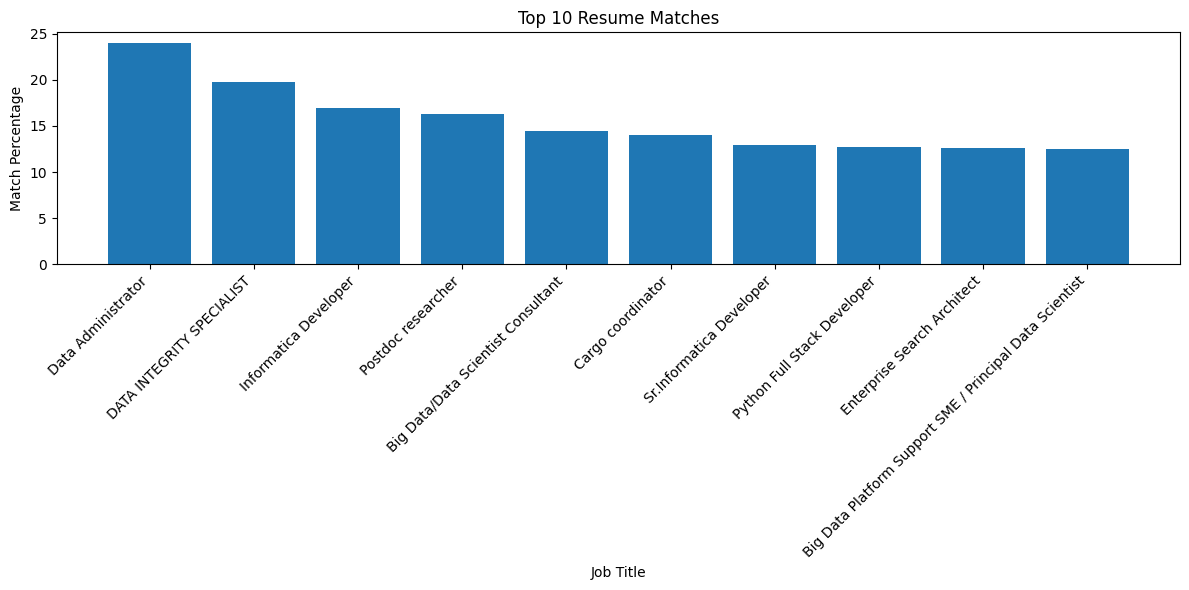

In [51]:
plt.figure(figsize=(12,6))

plt.bar(
    top_10["job_title"],
    top_10["Match Percentage"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Match Percentage")
plt.xlabel("Job Title")
plt.title("Top 10 Resume Matches")
plt.tight_layout()

plt.show()

In [52]:
# Enter your own Job Description

job_description = input("Enter Job Description:\n")

Enter Job Description:
Python Developer with experience in SQL, Machine Learning, Deep Learning, NLP, Power BI, Tableau, Pandas, NumPy, Scikit-learn and Data Analysis.


In [53]:
# Vectorize New Job Description

job_vector = tfidf.transform([job_description])

similarity = cosine_similarity(job_vector, resume_vectors)

df["Match Percentage"] = (similarity.flatten()*100).round(2)

top_candidates = df.sort_values(
    by="Match Percentage",
    ascending=False
)

In [54]:
# Display Top 10 Candidates

top_candidates[
    ["category","job_title","Match Percentage"]
].head(10)

,category,job_title,Match Percentage
5326,"Datawarehousing, ETL, Informatica Resumes",Data Administrator,27.49
1470,Web Developer Resumes,DATA INTEGRITY SPECIALIST,19.82
1854,Web Developer Resumes,Sr.Tableau Developer/Data Analyst,17.91
2416,SQL Developers Resumes,Postdoc researcher,17.84
1950,Web Developer Resumes,Sr. Tableau Developer/ Sr. Data Analyst,17.76
1840,Web Developer Resumes,Informatica Developer,17.72
1255,Web Developer Resumes,Tableau Developer,17.50
8354,Recruiter Resumes,Software Engineer,16.66
8398,Recruiter Resumes,Microstrtegy Developer,16.44
4428,Network and Systems Administrators Resumes,Jr. Administrator/Programmer,16.40


In [55]:
best = top_candidates.iloc[0]

print("="*60)
print("🏆 BEST MATCHING RESUME")
print("="*60)

print("Category :", best["category"])
print("Job Title:", best["job_title"])
print("Match %  :", best["Match Percentage"])

🏆 BEST MATCHING RESUME
Category : Datawarehousing, ETL, Informatica Resumes
Job Title: Data Administrator
Match %  : 27.49


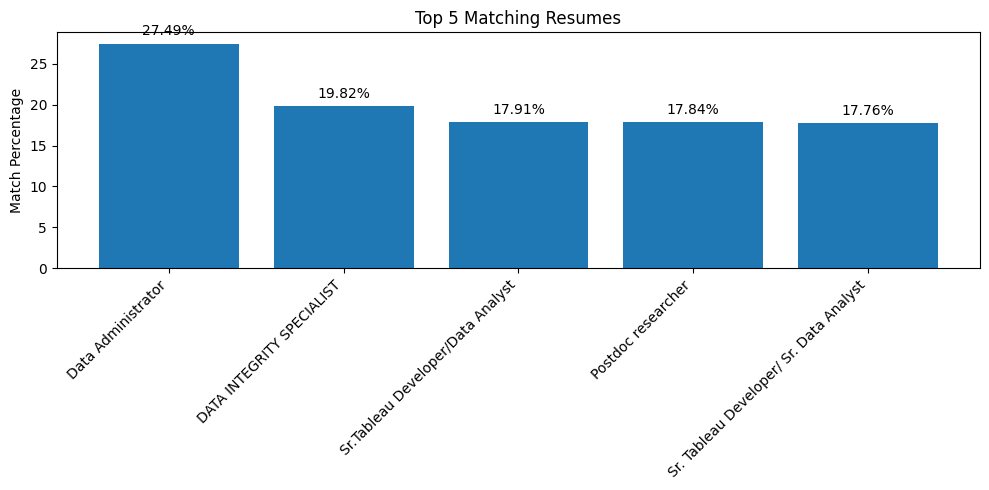

In [56]:
top5 = top_candidates.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5["job_title"],
    top5["Match Percentage"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Match Percentage")
plt.title("Top 5 Matching Resumes")

for i, value in enumerate(top5["Match Percentage"]):
    plt.text(i, value+1, str(value)+"%", ha="center")

plt.tight_layout()

plt.show()

In [57]:
top_candidates.to_csv(
    "Top_Resume_Matches.csv",
    index=False
)

print("Top Resume Matches saved successfully!")

Top Resume Matches saved successfully!


In [58]:
def resume_screening(job_description):

    job_vector = tfidf.transform([job_description])

    similarity = cosine_similarity(job_vector, resume_vectors)

    df["Match Percentage"] = (similarity.flatten()*100).round(2)

    top_candidates = df.sort_values(
        by="Match Percentage",
        ascending=False
    )

    return top_candidates[
        ["category", "job_title", "Match Percentage"]
    ].head(10)

In [59]:
job = """
Python Developer with SQL, Machine Learning,
Deep Learning, NLP, Power BI and Data Analysis
"""

resume_screening(job)

,category,job_title,Match Percentage
1470,Web Developer Resumes,DATA INTEGRITY SPECIALIST,25.78
2416,SQL Developers Resumes,Postdoc researcher,25.14
2528,SQL Developers Resumes,Enterprise Search Architect,20.07
1840,Web Developer Resumes,Informatica Developer,19.99
5326,"Datawarehousing, ETL, Informatica Resumes",Data Administrator,18.58
5232,"Datawarehousing, ETL, Informatica Resumes",Learning Management System IT Support Specialist,15.88
2135,SQL Developers Resumes,Freelance Trainer,15.36
8469,Recruiter Resumes,Python Developer,14.47
6201,"Business Intelligence, Business Object Resumes",Python Developer,14.03
6702,"Business Intelligence, Business Object Resumes",Python Developer,14.03


In [60]:
resume_screening(job)

,category,job_title,Match Percentage
1470,Web Developer Resumes,DATA INTEGRITY SPECIALIST,25.78
2416,SQL Developers Resumes,Postdoc researcher,25.14
2528,SQL Developers Resumes,Enterprise Search Architect,20.07
1840,Web Developer Resumes,Informatica Developer,19.99
5326,"Datawarehousing, ETL, Informatica Resumes",Data Administrator,18.58
5232,"Datawarehousing, ETL, Informatica Resumes",Learning Management System IT Support Specialist,15.88
2135,SQL Developers Resumes,Freelance Trainer,15.36
8469,Recruiter Resumes,Python Developer,14.47
6201,"Business Intelligence, Business Object Resumes",Python Developer,14.03
6702,"Business Intelligence, Business Object Resumes",Python Developer,14.03
